# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [87]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

In [88]:
import matplotlib.pyplot as plt

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

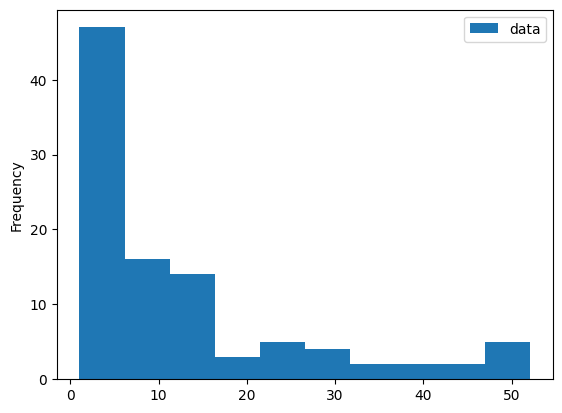

In [89]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

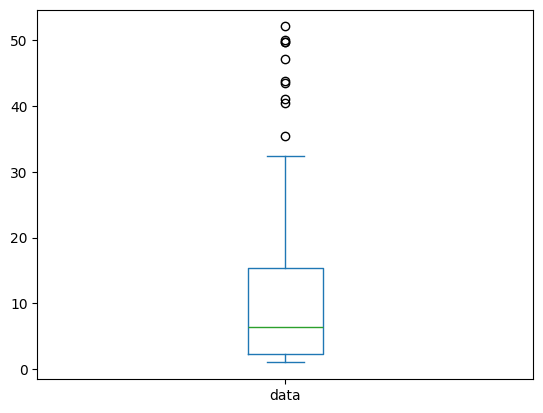

In [90]:
df.plot.box()

Comparing the histogram and box plot, I see that a pro for the histogram is that it is easy to understand the distribution. However a major con is that the histogram gives little context to what the values are being compared to in relation to the drug prices. On the other hand, a major pro to the box plot is that it gives information about the quartile and range, which helps gives more context to the prices. A possible con to the box plot is that someone who has never seen one may be confused by the layout. 

Between the two, I'd choose the box plot but I do think that there needs to be a proper title, axis labels, and a detailed legend so that even those without any knowledge of a box plot can understand the data being conveyed.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

## Loading in both Datasets

In [91]:
# Load in dataset
default_credit = pd.read_excel("Default_of_Credit_Card_Clients.xls")
bankruptcy_prediction = pd.read_csv("Taiwanese_Bankruptcy_Prediction.csv")

## Default of Credit Card Clients Dataset Analysis:

The current header is not informative and I believe the first row would be a better header, therefore is the next code blocks, I will be making this change.

In [92]:
# changong row 0 to be header and removing original header
default_credit.columns = default_credit.iloc[0]   
default_credit = default_credit[1:]  

Based on information from the UCI ML Repo, all the rows should be integers, however they are currently stored as objects.

In [93]:
# changing all cols from objects to integers
default_credit = default_credit.astype(int)

In [94]:
# Describe
default_credit.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Mean, Median, and Mode

In [95]:
# Mean
default_credit.mean()

0
ID                             15000.500000
LIMIT_BAL                     167484.322667
SEX                                1.603733
EDUCATION                          1.853133
MARRIAGE                           1.551867
AGE                               35.485500
PAY_0                             -0.016700
PAY_2                             -0.133767
PAY_3                             -0.166200
PAY_4                             -0.220667
PAY_5                             -0.266200
PAY_6                             -0.291100
BILL_AMT1                      51223.330900
BILL_AMT2                      49179.075167
BILL_AMT3                      47013.154800
BILL_AMT4                      43262.948967
BILL_AMT5                      40311.400967
BILL_AMT6                      38871.760400
PAY_AMT1                        5663.580500
PAY_AMT2                        5921.163500
PAY_AMT3                        5225.681500
PAY_AMT4                        4826.076867
PAY_AMT5                      

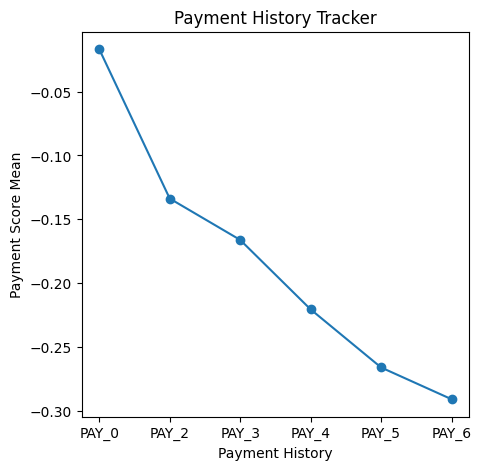

In [ ]:
# visualize score
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
plt.figure(figsize=(5,5))
pay_means = default_credit[pay_cols].mean()
plt.plot(pay_means.index, pay_means.values, marker='o')
plt.title("Payment History Tracker")
plt.xlabel("Payment History")
plt.ylabel("Payment Score Mean")
plt.show()

In [96]:
# Median
default_credit.median()

0
ID                             15000.5
LIMIT_BAL                     140000.0
SEX                                2.0
EDUCATION                          2.0
MARRIAGE                           2.0
AGE                               34.0
PAY_0                              0.0
PAY_2                              0.0
PAY_3                              0.0
PAY_4                              0.0
PAY_5                              0.0
PAY_6                              0.0
BILL_AMT1                      22381.5
BILL_AMT2                      21200.0
BILL_AMT3                      20088.5
BILL_AMT4                      19052.0
BILL_AMT5                      18104.5
BILL_AMT6                      17071.0
PAY_AMT1                        2100.0
PAY_AMT2                        2009.0
PAY_AMT3                        1800.0
PAY_AMT4                        1500.0
PAY_AMT5                        1500.0
PAY_AMT6                        1500.0
default payment next month         0.0
dtype: float64

In [97]:
# Mode
default_credit.mode().iloc[0]

0
ID                                1.0
LIMIT_BAL                     50000.0
SEX                               2.0
EDUCATION                         2.0
MARRIAGE                          2.0
AGE                              29.0
PAY_0                             0.0
PAY_2                             0.0
PAY_3                             0.0
PAY_4                             0.0
PAY_5                             0.0
PAY_6                             0.0
BILL_AMT1                         0.0
BILL_AMT2                         0.0
BILL_AMT3                         0.0
BILL_AMT4                         0.0
BILL_AMT5                         0.0
BILL_AMT6                         0.0
PAY_AMT1                          0.0
PAY_AMT2                          0.0
PAY_AMT3                          0.0
PAY_AMT4                          0.0
PAY_AMT5                          0.0
PAY_AMT6                          0.0
default payment next month        0.0
Name: 0, dtype: float64

### Histograms of all Columns

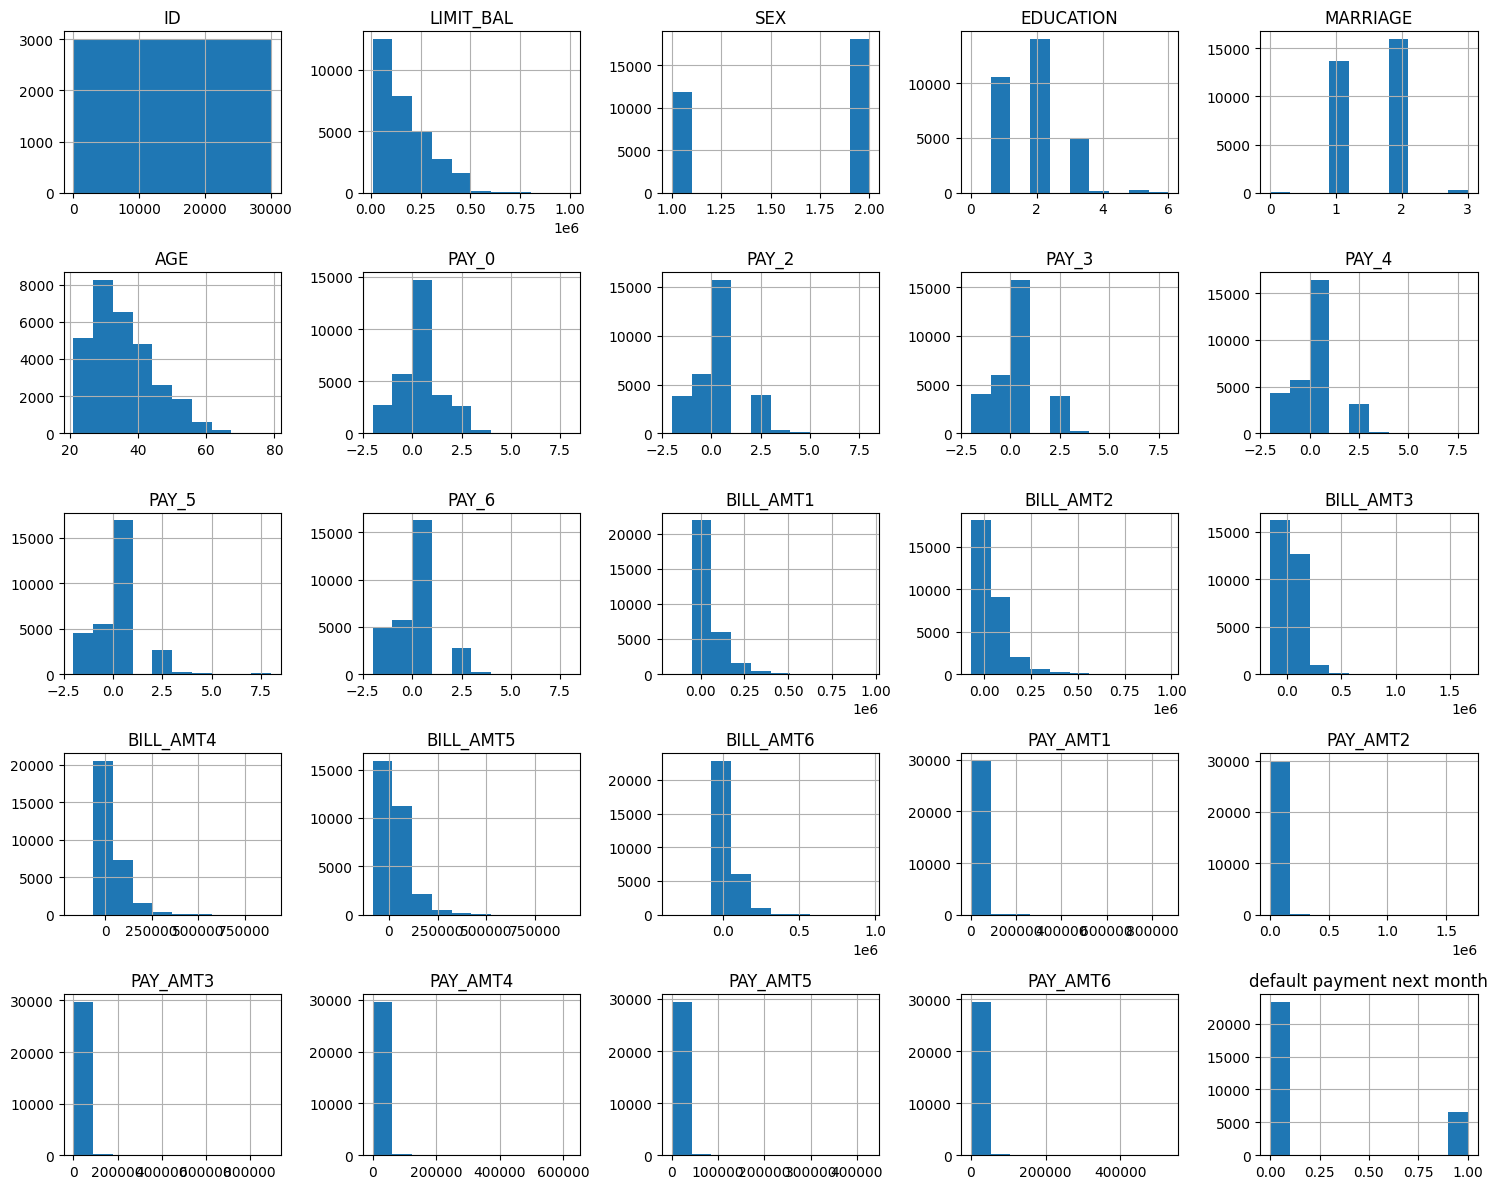

In [98]:
default_credit.hist(figsize=(15, 12), bins=10)
plt.tight_layout()
plt.show()

### Default Credit Conclusions:

Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data! 
- Yes the data is around what I expected. By looking at the mode and median, it shows that most people do not have credit card issues. However, when looking at the means of pay_0 to pay_6, it shows that although it is slightly negative (good), it's number is being dragged more positve (bad) by those that are delayed on payments. This is further shown with the graphs that show distributions lean to good credit, while there are outliers with bad credit. I do believe that this data is usable and reflects common credit card usage amongst a population.

What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?
- ID is uniform since every person has a unique ID. 
- Limit_BAL shows a left skewed distribution.
- Sex is discrete binomial as the dataset only catogorizes two genders.
- Education is tracked with integers 1 to 4, which shows a bell shaped distribution.
- Marriage is tracked with integers 1 to 3, which shows a bell shaped distribution.
- Age shows a left skewed distribtion which means most people are younger.
- pay_0 to pay_6 track a person's payments with a number in from -1 to 8, these columns are all discrete distributions which are bell shaped.
- All AMT columns are treated as continous data because they measure money. By looking at the histograms above, all AMT columns appear left skewed. 

Are there any outliers present?  (Data points that are far from the others.)
- Yes there are outliers. In every left skewed graph, the histogram shows that almost everyone falls under a single bin, however, there are a few outliers in the bins to the right.

If there are multiple related histograms, how does the distribution change across different groups?
- Many of my histograms are related since they track similar data. As shown on the histograms, although there are 6 pay, bill, and pay_amt columns, they all show very similar distributions amongst there respective category.

How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
- No, I did not find that the bin size revealed different patterns. I tried 15, 20, and 50 bins when I first made the graphs, but found that each one had the same distribtion, so I made it 10 bins so that the data was most visible.

In [113]:
# What are the minimum and maximum values represented in each histogram?
pd.DataFrame({
    'Min': default_credit.min(),
    'Max': default_credit.max()
})

,Min,Max
0,,
ID,1,30000
LIMIT_BAL,10000,1000000
SEX,1,2
EDUCATION,0,6
MARRIAGE,0,3
AGE,21,79
PAY_0,-2,8
PAY_2,-2,8
PAY_3,-2,8


## Taiwanese Backruptcy Prediction Analysis:

In [100]:
bankruptcy_prediction.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [101]:
# describe
bankruptcy_prediction.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


### Mean, Median, and Mode

In [102]:
# Mean
bankruptcy_prediction.mean()

Bankrupt?                                                   0.032263
 ROA(C) before interest and depreciation before interest    0.505180
 ROA(A) before interest and % after tax                     0.558625
 ROA(B) before interest and depreciation after tax          0.553589
 Operating Gross Margin                                     0.607948
                                                              ...   
 Liability to Equity                                        0.280365
 Degree of Financial Leverage (DFL)                         0.027541
 Interest Coverage Ratio (Interest expense to EBIT)         0.565358
 Net Income Flag                                            1.000000
 Equity to Liability                                        0.047578
Length: 96, dtype: float64

In [103]:
# Median
bankruptcy_prediction.median()

Bankrupt?                                                   0.000000
 ROA(C) before interest and depreciation before interest    0.502706
 ROA(A) before interest and % after tax                     0.559802
 ROA(B) before interest and depreciation after tax          0.552278
 Operating Gross Margin                                     0.605997
                                                              ...   
 Liability to Equity                                        0.278778
 Degree of Financial Leverage (DFL)                         0.026808
 Interest Coverage Ratio (Interest expense to EBIT)         0.565252
 Net Income Flag                                            1.000000
 Equity to Liability                                        0.033798
Length: 96, dtype: float64

In [104]:
# Mode
bankruptcy_prediction.mode().iloc[0]

Bankrupt?                                                   0.000000
 ROA(C) before interest and depreciation before interest    0.490128
 ROA(A) before interest and % after tax                     0.559693
 ROA(B) before interest and depreciation after tax          0.538787
 Operating Gross Margin                                     0.598956
                                                              ...   
 Liability to Equity                                        0.000000
 Degree of Financial Leverage (DFL)                         0.026791
 Interest Coverage Ratio (Interest expense to EBIT)         0.565158
 Net Income Flag                                            1.000000
 Equity to Liability                                        0.000000
Name: 0, Length: 96, dtype: float64

### Graphs of all Columns

I had an issue with the percentage sign in second column, so I've change it to _pct.

In [ ]:
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.replace('%', '_pct')

Name of all Cols:

In [106]:
bankruptcy_prediction.columns.to_list()

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and _pct after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Non-industry income and expenditure/revenue',
 ' Continuous interest rate (after tax)',
 ' Operating Expense Rate',
 ' Research and development expense rate',
 ' Cash flow rate',
 ' Interest-bearing debt interest rate',
 ' Tax rate (A)',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Persistent EPS in the Last Four Seasons',
 ' Cash Flow Per Share',
 ' Revenue Per Share (Yuan ¥)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' After-tax Net Profit Growth Rate',
 ' Regular Net Profit Growth Rate',
 

I noticed that there was a space in front of each column name, so I will removing the space in the following code. 

In [107]:
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.strip()

In [108]:
# confirming that the space was removed
bankruptcy_prediction.columns.to_list()

['Bankrupt?',
 'ROA(C) before interest and depreciation before interest',
 'ROA(A) before interest and _pct after tax',
 'ROA(B) before interest and depreciation after tax',
 'Operating Gross Margin',
 'Realized Sales Gross Margin',
 'Operating Profit Rate',
 'Pre-tax net Interest Rate',
 'After-tax net Interest Rate',
 'Non-industry income and expenditure/revenue',
 'Continuous interest rate (after tax)',
 'Operating Expense Rate',
 'Research and development expense rate',
 'Cash flow rate',
 'Interest-bearing debt interest rate',
 'Tax rate (A)',
 'Net Value Per Share (B)',
 'Net Value Per Share (A)',
 'Net Value Per Share (C)',
 'Persistent EPS in the Last Four Seasons',
 'Cash Flow Per Share',
 'Revenue Per Share (Yuan ¥)',
 'Operating Profit Per Share (Yuan ¥)',
 'Per Share Net profit before tax (Yuan ¥)',
 'Realized Sales Gross Profit Growth Rate',
 'Operating Profit Growth Rate',
 'After-tax Net Profit Growth Rate',
 'Regular Net Profit Growth Rate',
 'Continuous Net Profit Grow

### Histograms of all Columns

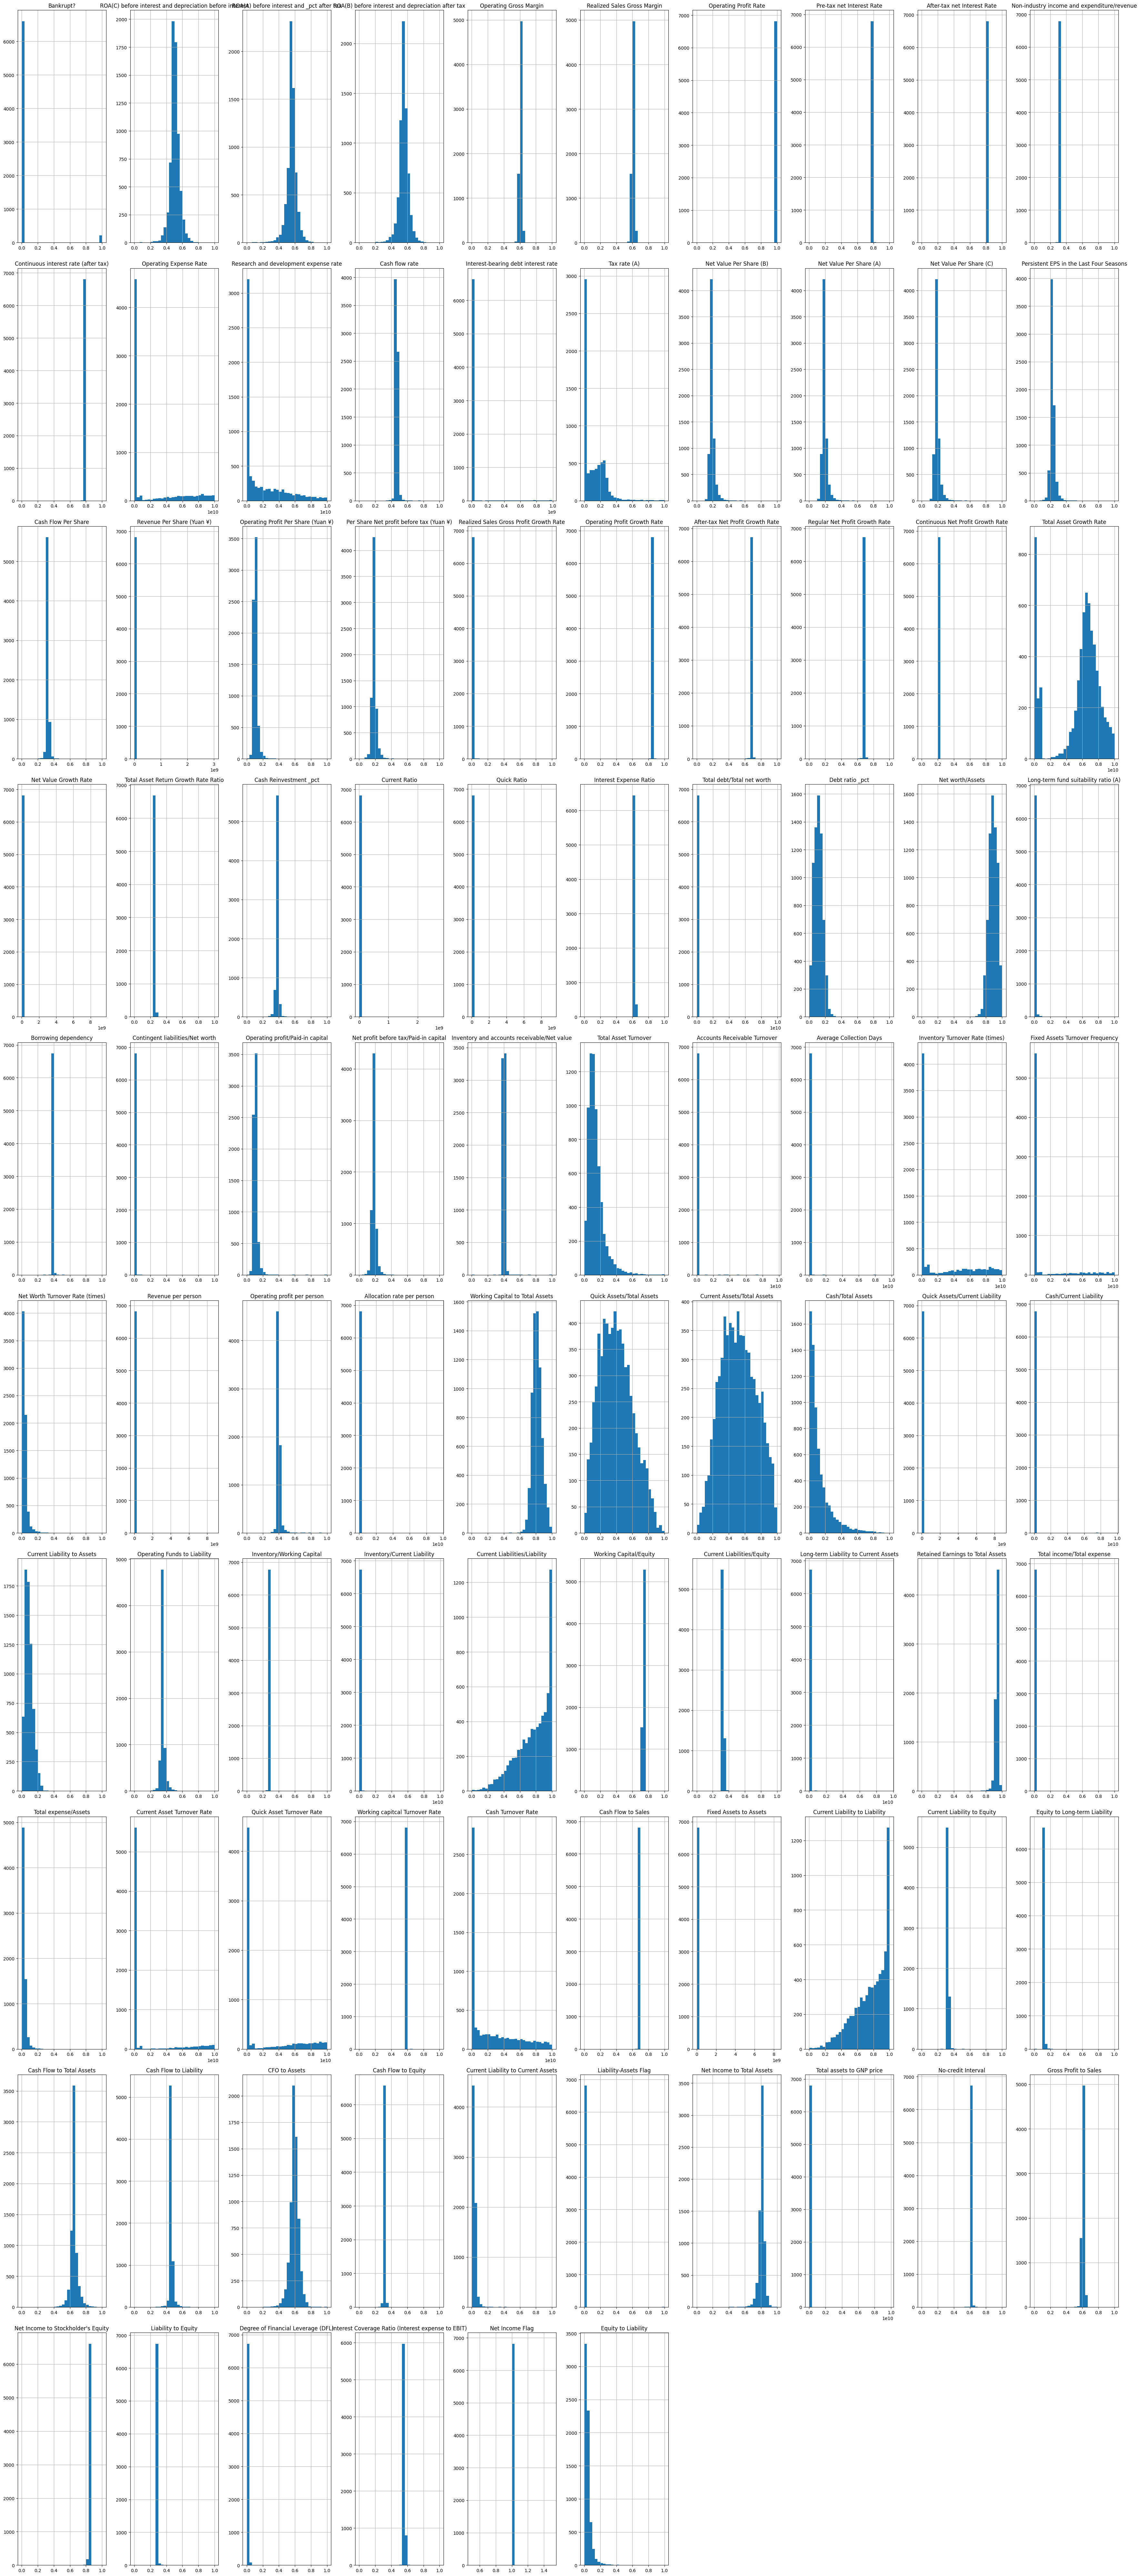

In [112]:
bankruptcy_prediction.hist(figsize=(35, 80), bins=30)
plt.tight_layout()
plt.show()

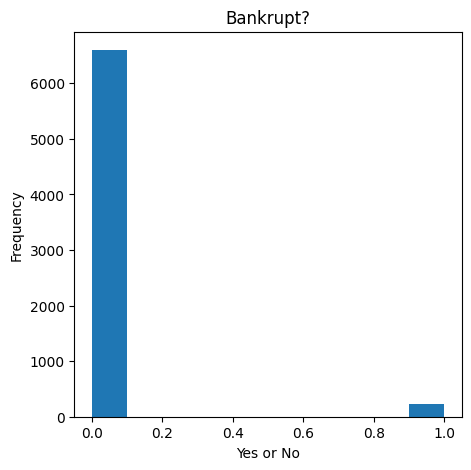

In [130]:
plt.figure(figsize=(5,5))
plt.hist(bankruptcy_prediction["Bankrupt?"], bins=10)
plt.title("Bankrupt?")
plt.xlabel("Yes or No")
plt.ylabel("Frequency")
plt.show()

### Bankruptcy Prediction Conclusions:

Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable? 
- Yes the data is around what I expected. Based on the histograms, I see that most businesses tend to fall under the same bin. This is what I expected because I believe businesses that do file for bankruptcy is relatively low and will be the few outlier.

What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?
- For most featues, the overall shape of te distribution is left skewed. There are some columns like CFO to Assests, ROA, and Cash Flow to Total Assests that do show more normal distributions. Additionally, Net Income to Total Assests, Current Liability to Liability, Current Liabilities/Liability, Working Capital to Total Assests, Retained Earnings to Total Assests, and Net Worth/Assests all show right skewed distributions.

Are there any outliers present?  (Data points that are far from the others.)
- Yes there are outliers. In almost every histogram, it shows that other then the most populated bin, there are much smaller bins that represent these outliers.

If there are multiple related histograms, how does the distribution change across different groups?
- Many of my histograms are related since they track similar data. For example, there are 3 different ROA that tracke different interests. Additionally many of the columns track liability and total assests. Overall, these graphs show very similar data distributions.

How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
- No, I did not find that the bin size revealed different patterns. I tried 10, 20, 40, and 80 bins when I was trying to fix the layout of my graphs, however, I found that most of these graphs looked the same and did not reveal any new patterns.

In [114]:
# What are the minimum and maximum values represented in each histogram?
pd.DataFrame({
    'Min': bankruptcy_prediction.min(),
    'Max': bankruptcy_prediction.max()
})

,Min,Max
Bankrupt?,0.0,1.0
ROA(C) before interest and depreciation before interest,0.0,1.0
ROA(A) before interest and _pct after tax,0.0,1.0
ROA(B) before interest and depreciation after tax,0.0,1.0
Operating Gross Margin,0.0,1.0
...,...,...
Liability to Equity,0.0,1.0
Degree of Financial Leverage (DFL),0.0,1.0
Interest Coverage Ratio (Interest expense to EBIT),0.0,1.0
Net Income Flag,1.0,1.0


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

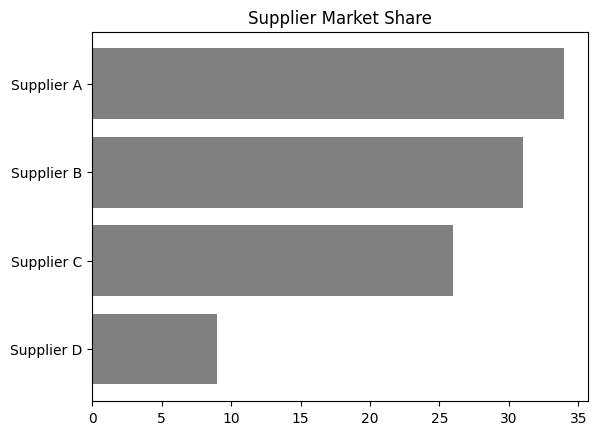

In [119]:
categories = ['Supplier A', 'Supplier B', 'Supplier C', 'Supplier D']
pct = [34, 31, 26, 9]

plt.barh(categories, pct, color='grey')
plt.title("Supplier Market Share")
plt.gca().invert_yaxis()